# Advanced Statistical Analysis of Apple Inc. (AAPL) Stock Data


**Dataset:** `Apple_Stock_Prices.csv`

This notebook conducts an advanced statistical study of Apple Inc. daily stock
prices using **NumPy**, **SciPy**, **Pandas**, and **Matplotlib**. The goal is to
master statistical analysis of financial time-series data, build effective
visualizations of price/volume trends, and apply hypothesis testing to extract
meaningful, data-driven insights.

### Notebook structure
1. **Data Loading and Exploration**
2. **Data Visualization**
3. **Statistical Analysis**
4. **Hypothesis Testing**
5. **Advanced Statistical Techniques (Bonus)**
   - Signal Processing using SciPy
   - Statistical Functions in NumPy
6. **Summary and Insights**
7. **Reflection**

### Column dictionary
| Column | Meaning |
|---|---|
| `Date` | Trading date |
| `Open` | Opening price |
| `High` | Intraday high |
| `Low` | Intraday low |
| `Close` | Closing price |
| `Adj Close` | Close adjusted for splits/dividends |
| `Volume` | Number of shares traded |


## 1. Data Loading and Exploration

We load the data with Pandas, parse the `Date` column (the file uses the
**day-first** `DD/MM/YYYY` format), inspect data types, check for missing values,
and study the time-series properties (date range, frequency, gaps).

In [1]:
# Core scientific stack
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats, signal

# Display / plotting defaults
plt.style.use("seaborn-v0_8-darkgrid")
plt.rcParams["figure.figsize"] = (13, 5)
plt.rcParams["axes.titlesize"] = 13
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

In [2]:
# Load the dataset. The dates are day-first (e.g. 02/01/1981 = 2 Jan 1981).
df = pd.read_csv("Apple_Stock_Prices.csv", parse_dates=["Date"], dayfirst=True)

print(f"Shape: {df.shape[0]:,} rows x {df.shape[1]} columns")
df.head()

Shape: 10,608 rows x 7 columns


,Date,Open,High,Low,Close,Adj Close,Volume
0,1981-01-02,0.1540,0.1551,0.1540,0.1540,0.1198,21660800
1,1981-01-05,0.1512,0.1512,0.1507,0.1507,0.1172,35728000
2,1981-01-06,0.1445,0.1445,0.1440,0.1440,0.1120,45158400
3,1981-01-07,0.1384,0.1384,0.1378,0.1378,0.1073,55686400
4,1981-01-08,0.1356,0.1356,0.1350,0.1350,0.1051,39827200


In [3]:
# Data types and non-null counts
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10608 entries, 0 to 10607
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       10608 non-null  datetime64[us]
 1   Open       10608 non-null  float64       
 2   High       10608 non-null  float64       
 3   Low        10608 non-null  float64       
 4   Close      10608 non-null  float64       
 5   Adj Close  10608 non-null  float64       
 6   Volume     10608 non-null  int64         
dtypes: datetime64[us](1), float64(5), int64(1)
memory usage: 580.3 KB


In [4]:
# Missing-value audit
missing = df.isnull().sum()
print("Null values per column:")
print(missing)
print(f"\nTotal nulls: {missing.sum()}")
print(f"Duplicate rows: {df.duplicated().sum()}")
print(f"Duplicate dates: {df['Date'].duplicated().sum()}")

Null values per column:
Date         0
Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

Total nulls: 0
Duplicate rows: 0
Duplicate dates: 0


### Time-series properties

We sort chronologically, set `Date` as the index, and examine the span,
the number of trading days, and the calendar gaps between consecutive
observations (weekends/holidays mean the series is *not* a continuous daily
frequency).

In [11]:
# Sort chronologically and index by date.
# Self-healing / idempotent: works no matter what state `df` is in, so the cell
# is safe to re-run or run out of order.
if "Date" in df.columns:
    # Fresh load: Date is still a column -> set it as the index.
    df = df.sort_values("Date").reset_index(drop=True).set_index("Date")
elif not isinstance(df.index, pd.DatetimeIndex):
    # Date is neither a column nor the index (e.g. cell run out of order):
    # reload from the CSV to recover a clean, correctly-typed state.
    df = pd.read_csv("Apple_Stock_Prices.csv", parse_dates=["Date"], dayfirst=True)
    df = df.sort_values("Date").reset_index(drop=True).set_index("Date")
# else: Date is already the DatetimeIndex -> nothing to do.

print(f"Date range : {df.index.min().date()}  ->  {df.index.max().date()}")
print(f"Span       : {(df.index.max() - df.index.min()).days:,} calendar days")
print(f"Observations: {len(df):,} trading days")

# Gaps between consecutive trading days
gaps = df.index.to_series().diff().dt.days.dropna()
print("\nGap (calendar days) between consecutive rows:")
print(gaps.value_counts().sort_index().head(8))
print("\n-> 1-day gaps dominate within the week; 3-day gaps are weekends; "
      "larger gaps are market holidays. The series is *business-day*, not daily.")

Date range : 1981-01-02  ->  2023-01-27
Span       : 15,365 calendar days
Observations: 10,608 trading days

Gap (calendar days) between consecutive rows:
Date
1.0000    8317
2.0000      95
3.0000    1927
4.0000     265
5.0000       2
7.0000       1
Name: count, dtype: int64

-> 1-day gaps dominate within the week; 3-day gaps are weekends; larger gaps are market holidays. The series is *business-day*, not daily.


In [12]:
# Quick statistical fingerprint of every numeric column
df.describe()

,Open,High,Low,Close,Adj Close,Volume
count,"10,608.0000","10,608.0000","10,608.0000","10,608.0000","10,608.0000","10,608.0000"
mean,16.6892,16.8800,16.5008,16.6974,16.0273,"327,509,817.2606"
std,35.4505,35.8828,35.0313,35.4739,35.1549,"337,820,279.0577"
min,0.0497,0.0497,0.0491,0.0491,0.0382,0.0000
25%,0.2879,0.2969,0.2824,0.2889,0.2389,"121,304,400.0000"
50%,0.4888,0.4955,0.4804,0.4877,0.4049,"214,597,600.0000"
75%,16.3209,16.4185,16.1512,16.2696,14.0732,"406,680,400.0000"
max,182.6300,182.9400,179.1200,182.0100,180.9597,"7,421,640,800.0000"


## 2. Data Visualization

We visualise the long-run trend in closing price and traded volume, then build a
**candlestick chart** (Open/High/Low/Close) for a recent window to inspect
short-term price action.

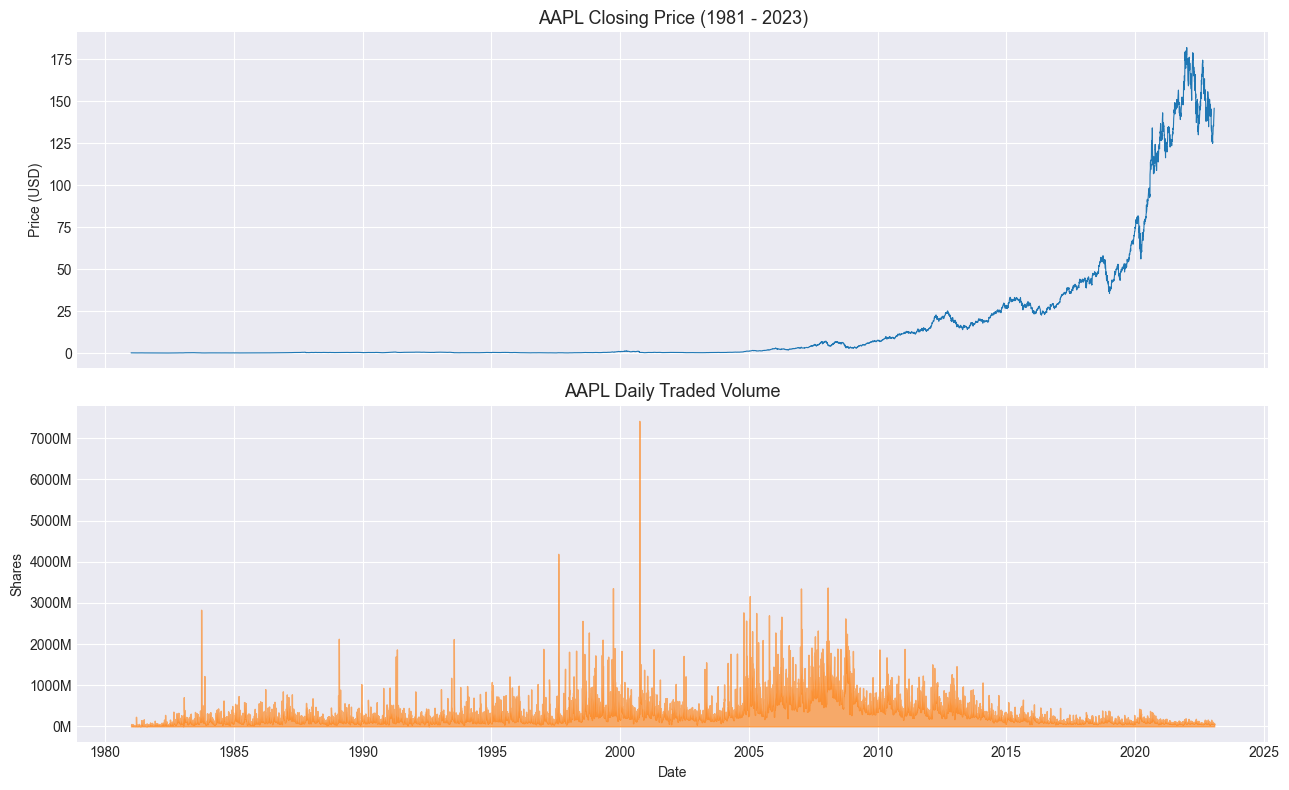

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

ax1.plot(df.index, df["Close"], color="#1f77b4", lw=0.8)
ax1.set_title("AAPL Closing Price (1981 - 2023)")
ax1.set_ylabel("Price (USD)")

ax2.fill_between(df.index, df["Volume"], color="#ff7f0e", alpha=0.6)
ax2.set_title("AAPL Daily Traded Volume")
ax2.set_ylabel("Shares")
ax2.set_xlabel("Date")
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v/1e6:.0f}M"))

plt.tight_layout()
plt.show()

**Observation.** Closing price is essentially flat for the first ~25 years and
then grows explosively after ~2005 (iPod/iPhone era) — note how a linear axis
hides early-period variation. Volume spiked enormously in the late 1990s-2000s and
has trended *down* in share-count terms as the price rose (post stock-splits the
dollar-volume remains huge).

A **log-scale** price chart makes the early decades comparable to recent ones.

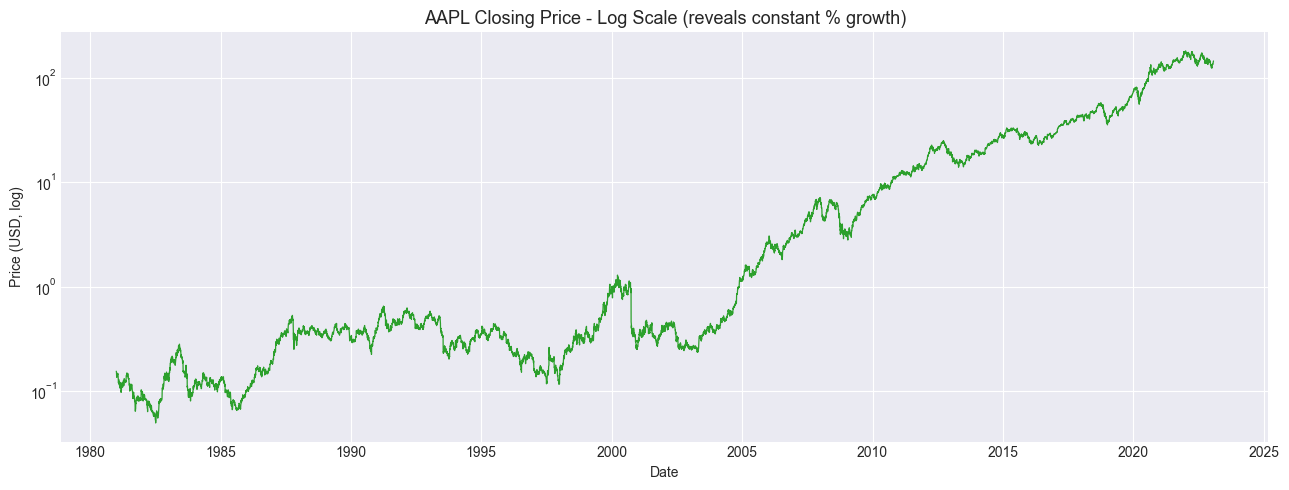

In [14]:
fig, ax = plt.subplots(figsize=(13, 5))
ax.semilogy(df.index, df["Close"], color="#2ca02c", lw=0.9)
ax.set_title("AAPL Closing Price - Log Scale (reveals constant % growth)")
ax.set_ylabel("Price (USD, log)")
ax.set_xlabel("Date")
plt.tight_layout()
plt.show()

### Candlestick chart

`mplfinance` is not installed, so we draw the candlesticks manually with
Matplotlib primitives: a thin **wick** (`vlines`) from Low to High, and a thicker
**body** (`bar`) between Open and Close. Green = up day (Close >= Open),
red = down day. We use the most recent ~90 trading days so individual candles are
legible.

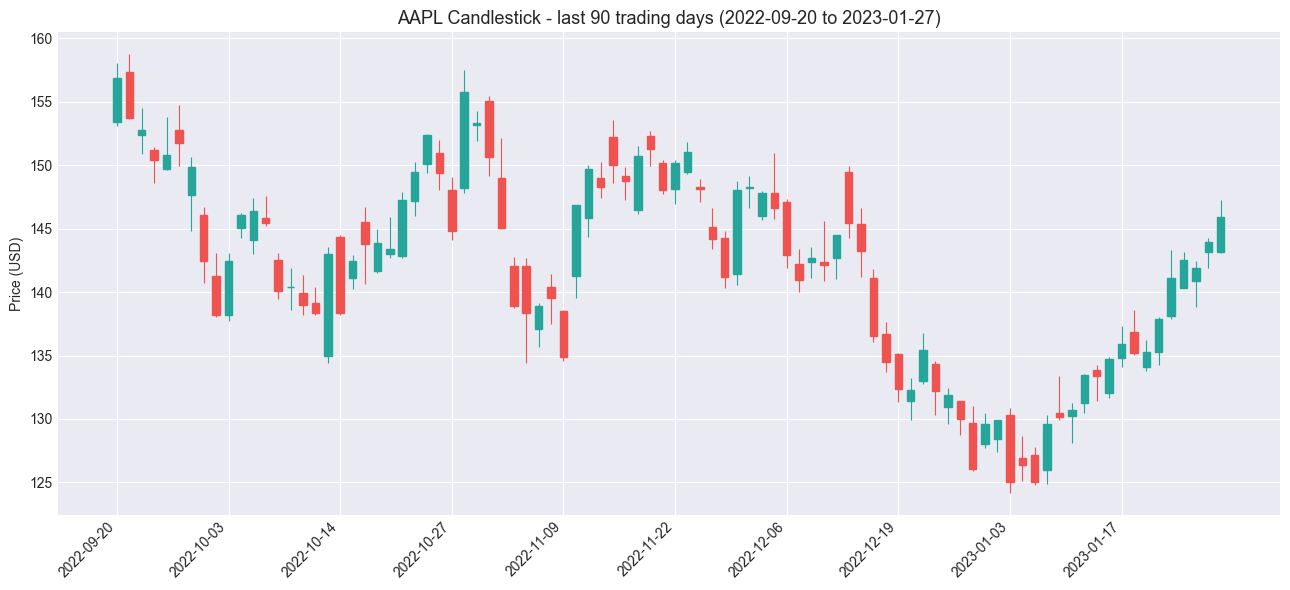

In [15]:
def plot_candlestick(data, ax, title=""):
    """Manual OHLC candlestick on a categorical x-axis (no weekend gaps)."""
    x = np.arange(len(data))
    up = data["Close"] >= data["Open"]
    colors = np.where(up, "#26a69a", "#ef5350")

    # Wicks: low -> high
    ax.vlines(x, data["Low"], data["High"], color=colors, lw=0.8)
    # Bodies: open -> close
    ax.bar(x, (data["Close"] - data["Open"]), bottom=data["Open"],
           width=0.6, color=colors, edgecolor=colors)

    # Label a subset of dates on the categorical axis
    step = max(1, len(data) // 10)
    ax.set_xticks(x[::step])
    ax.set_xticklabels([d.strftime("%Y-%m-%d") for d in data.index[::step]],
                       rotation=45, ha="right")
    ax.set_title(title)
    ax.set_ylabel("Price (USD)")

recent = df.iloc[-90:]
fig, ax = plt.subplots(figsize=(13, 6))
plot_candlestick(recent, ax,
                 title=f"AAPL Candlestick - last 90 trading days "
                       f"({recent.index.min().date()} to {recent.index.max().date()})")
plt.tight_layout()
plt.show()

## 3. Statistical Analysis

We compute summary statistics (mean, median, standard deviation, and dispersion
measures) for the key columns, then smooth the closing price with **moving
averages** to separate trend from noise.

In [16]:
key_cols = ["Open", "High", "Low", "Close", "Adj Close", "Volume"]

summary = pd.DataFrame({
    "mean":   df[key_cols].mean(),
    "median": df[key_cols].median(),
    "std":    df[key_cols].std(),
    "min":    df[key_cols].min(),
    "max":    df[key_cols].max(),
    "skew":   df[key_cols].skew(),
})
summary

,mean,median,std,min,max,skew
Open,16.6892,0.4888,35.4505,0.0497,182.6300,2.8737
High,16.8800,0.4955,35.8828,0.0497,182.9400,2.8764
Low,16.5008,0.4804,35.0313,0.0491,179.1200,2.8708
Close,16.6974,0.4877,35.4739,0.0491,182.0100,2.8737
Adj Close,16.0273,0.4049,35.1549,0.0382,180.9597,2.9388
Volume,"327,509,817.2606","214,597,600.0000","337,820,279.0577",0.0000,"7,421,640,800.0000",3.5514


The mean of every price column sits **well above** its median, and skewness is
strongly positive — the hallmark of a series that spent decades at low prices and
only recently reached high levels (a right-skewed, non-stationary distribution).

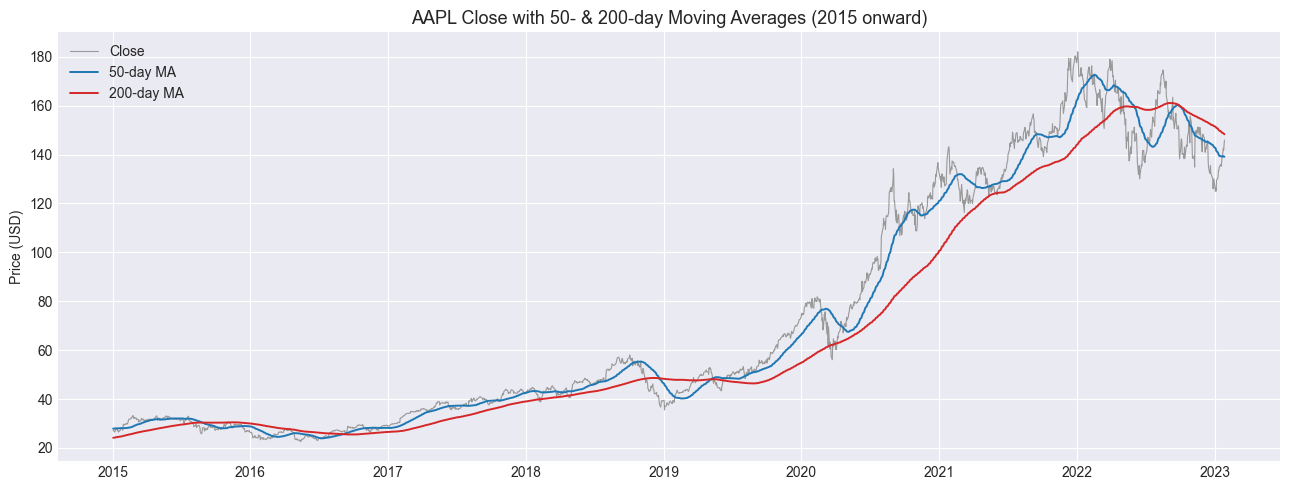

In [17]:
# Moving averages: 50-day (short/medium trend) and 200-day (long trend)
df["MA50"]  = df["Close"].rolling(window=50).mean()
df["MA200"] = df["Close"].rolling(window=200).mean()

fig, ax = plt.subplots(figsize=(13, 5))
recent = df.loc["2015":]
ax.plot(recent.index, recent["Close"], color="#999999", lw=0.8, label="Close")
ax.plot(recent.index, recent["MA50"],  color="#1f77b4", lw=1.4, label="50-day MA")
ax.plot(recent.index, recent["MA200"], color="#d62728", lw=1.4, label="200-day MA")
ax.set_title("AAPL Close with 50- & 200-day Moving Averages (2015 onward)")
ax.set_ylabel("Price (USD)")
ax.legend()
plt.tight_layout()
plt.show()

**Reading the moving averages.** When the 50-day MA crosses *above* the 200-day MA
it is a bullish "golden cross"; the reverse is a bearish "death cross". From 2015
onward the 50-day line sits above the 200-day for most of the strong uptrend, with
brief death crosses around the major drawdowns (late-2018, 2020 crash, 2022).

## 4. Hypothesis Testing

### 4.1 t-test - are average closing prices different across years?

We compare daily closing prices for **2021** vs **2022** with an independent
two-sample t-test (Welch's, which does not assume equal variances).

- **H0:** the mean closing price is the same in 2021 and 2022.
- **H1:** the mean closing prices differ.

In [18]:
close_2021 = df.loc["2021", "Close"].values
close_2022 = df.loc["2022", "Close"].values

t_stat, p_val = stats.ttest_ind(close_2021, close_2022, equal_var=False)

print(f"2021: n={len(close_2021):3d}  mean={close_2021.mean():.2f}  std={close_2021.std(ddof=1):.2f}")
print(f"2022: n={len(close_2022):3d}  mean={close_2022.mean():.2f}  std={close_2022.std(ddof=1):.2f}")
print(f"\nWelch t-statistic = {t_stat:.4f}")
print(f"p-value           = {p_val:.3e}")

alpha = 0.05
verdict = "REJECT H0" if p_val < alpha else "FAIL TO REJECT H0"
print(f"\nAt alpha={alpha}: {verdict}")

2021: n=252  mean=140.99  std=14.66
2022: n=251  mean=154.84  std=13.06

Welch t-statistic = -11.1866
p-value           = 4.710e-26

At alpha=0.05: REJECT H0


**Caveat (important for financial data).** Daily prices are highly
autocorrelated, so the independence assumption behind the t-test is violated;
the test treats ~250 correlated days as 250 independent draws and therefore
*overstates* significance. We report it as the exercise requires, but the honest
conclusion is "the 2021 and 2022 price *levels* are clearly different," which the
chart already shows. The statistically sound object to test is **daily returns**,
which we examine next.

### 4.2 Daily returns - distribution and normality test

We compute daily simple returns, visualise their distribution, and formally test
for normality with SciPy. Because the sample is large (>5,000), the Shapiro-Wilk
test is unreliable, so we use **D'Agostino-Pearson** (`normaltest`) and
**Jarque-Bera**, and back them with a Q-Q plot.

- **H0:** daily returns are normally distributed.
- **H1:** they are not.

In [19]:
returns = df["Close"].pct_change().dropna()

print(f"Daily returns: n={len(returns):,}")
print(f"  mean     = {returns.mean():.5f}  ({returns.mean()*252:.2%} annualised)")
print(f"  std      = {returns.std():.5f}  ({returns.std()*np.sqrt(252):.2%} annualised vol)")
print(f"  skewness = {stats.skew(returns):.4f}")
print(f"  kurtosis = {stats.kurtosis(returns):.4f}  (excess; 0 = normal)")

# Normality tests
k2, p_norm = stats.normaltest(returns)
jb, p_jb   = stats.jarque_bera(returns)
print(f"\nD'Agostino-Pearson: stat={k2:.1f},  p={p_norm:.3e}")
print(f"Jarque-Bera       : stat={jb:.1f},  p={p_jb:.3e}")
print(f"\n-> p << 0.05 in both: REJECT normality. Returns have fat tails / excess kurtosis.")

Daily returns: n=10,607
  mean     = 0.00105  (26.51% annualised)
  std      = 0.02824  (44.82% annualised vol)
  skewness = -0.3752
  kurtosis = 18.1252  (excess; 0 = normal)

D'Agostino-Pearson: stat=2719.2,  p=0.000e+00
Jarque-Bera       : stat=145441.8,  p=0.000e+00

-> p << 0.05 in both: REJECT normality. Returns have fat tails / excess kurtosis.


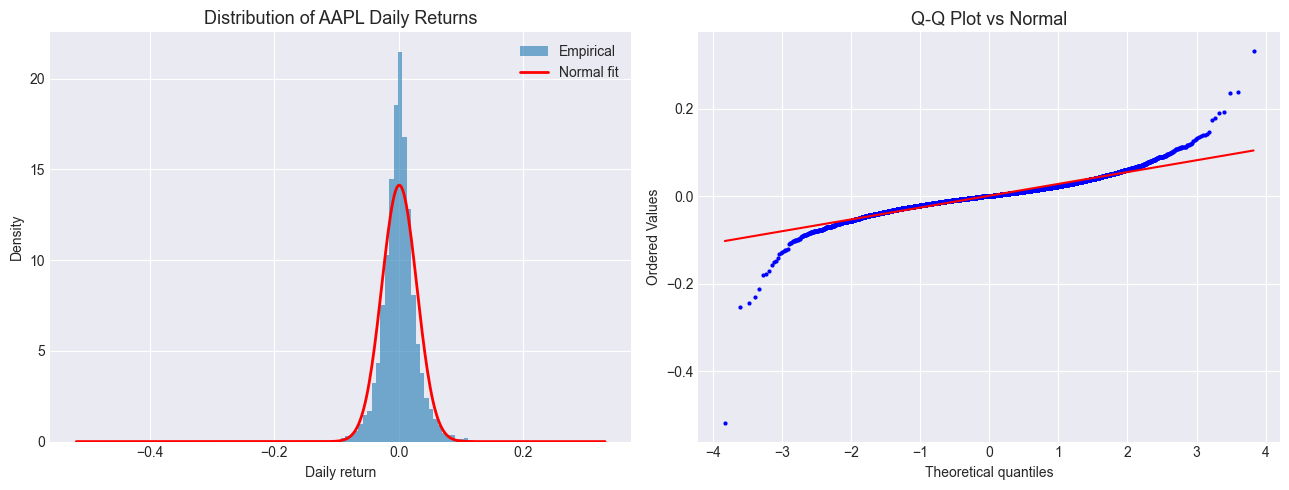

In [20]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

# Histogram vs fitted normal
ax1.hist(returns, bins=120, density=True, alpha=0.6, color="#1f77b4", label="Empirical")
xs = np.linspace(returns.min(), returns.max(), 400)
ax1.plot(xs, stats.norm.pdf(xs, returns.mean(), returns.std()),
         "r-", lw=2, label="Normal fit")
ax1.set_title("Distribution of AAPL Daily Returns")
ax1.set_xlabel("Daily return"); ax1.set_ylabel("Density"); ax1.legend()

# Q-Q plot
stats.probplot(returns, dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot vs Normal")
ax2.get_lines()[0].set_markersize(2)

plt.tight_layout()
plt.show()

**Finding.** The histogram is sharply **peaked** with **fat tails**, and the Q-Q
plot bends away from the line at both ends — extreme daily moves happen far more
often than a normal distribution predicts. This *leptokurtosis* is a universal
"stylised fact" of financial returns and is why risk models built on normality
under-estimate crash risk.

## 5. Advanced Statistical Techniques (Bonus)

### 5.1 Signal Processing using SciPy

A stock price is a noisy signal. We compare three smoothers on a recent window:
1. **`np.convolve`** — a simple boxcar (equal-weight) moving average.
2. **`scipy.signal.savgol_filter`** — a Savitzky-Golay filter that fits local
   polynomials, preserving peaks/turning points better than a plain average.
3. **`scipy.signal.detrend`** — removes the linear trend to expose the cyclical
   residual.

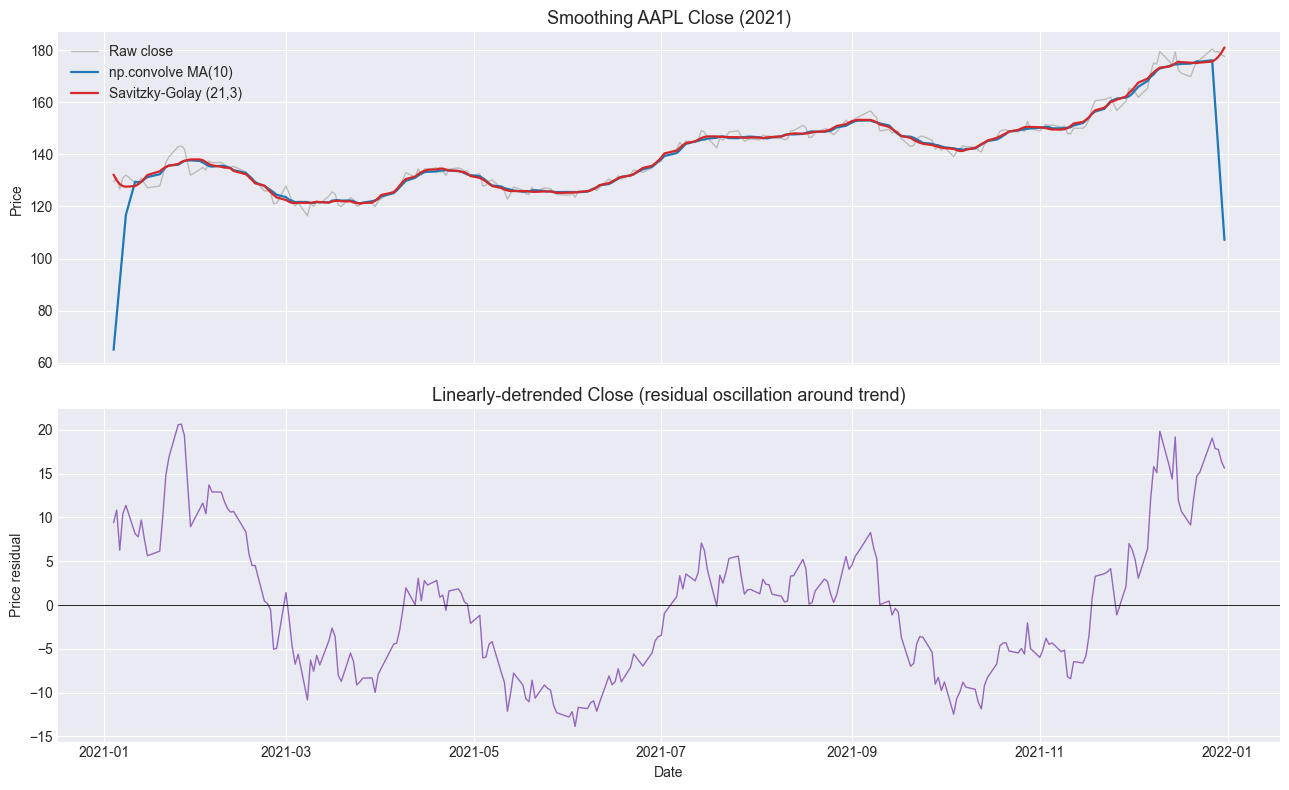

In [21]:
window = "2021"
price = df.loc[window, "Close"].values
idx   = df.loc[window].index

# 1) Boxcar moving average via np.convolve
N = 10
kernel = np.ones(N) / N
ma_conv = np.convolve(price, kernel, mode="same")

# 2) Savitzky-Golay smoother
savgol = signal.savgol_filter(price, window_length=21, polyorder=3)

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)
ax1.plot(idx, price,   color="#bbbbbb", lw=1, label="Raw close")
ax1.plot(idx, ma_conv, color="#1f77b4", lw=1.6, label=f"np.convolve MA({N})")
ax1.plot(idx, savgol,  color="#d62728", lw=1.6, label="Savitzky-Golay (21,3)")
ax1.set_title(f"Smoothing AAPL Close ({window})"); ax1.set_ylabel("Price"); ax1.legend()

# 3) Detrend -> residual signal
resid = signal.detrend(price)
ax2.plot(idx, resid, color="#9467bd", lw=1)
ax2.axhline(0, color="k", lw=0.6)
ax2.set_title("Linearly-detrended Close (residual oscillation around trend)")
ax2.set_ylabel("Price residual"); ax2.set_xlabel("Date")
plt.tight_layout(); plt.show()

**Observation.** The Savitzky-Golay filter tracks turning points more faithfully
than the boxcar average (which lags and rounds off peaks), while still removing
day-to-day jitter. The detrended residual shows AAPL oscillating around its 2021
upward trend.

### 5.2 Statistical Functions in NumPy - correlation analysis

Using **`np.corrcoef`** we quantify relationships between financial metrics. We
test the common market hypothesis that **price moves and volume are related**, and
examine how the correlation between the *moving average of price* and the *moving
average of volume* behaves across time periods (early vs recent era).

Correlation matrix (np.corrcoef):


,Open,High,Low,Close,Volume
Open,1.0000,0.9999,0.9999,0.9998,-0.2148
High,0.9999,1.0000,0.9999,0.9999,-0.2142
Low,0.9999,0.9999,1.0000,0.9999,-0.2156
Close,0.9998,0.9999,0.9999,1.0000,-0.2149
Volume,-0.2148,-0.2142,-0.2156,-0.2149,1.0000


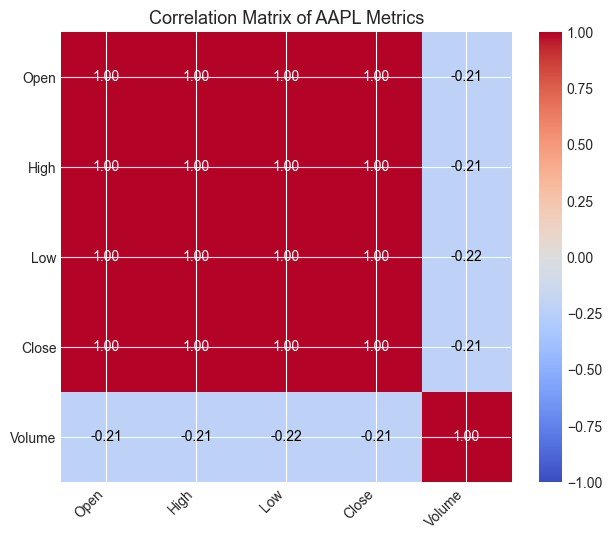

In [22]:
# --- (a) Correlation matrix of the core metrics (NumPy) ---
metrics = df[["Open", "High", "Low", "Close", "Volume"]].dropna()
corr = np.corrcoef(metrics.values, rowvar=False)
corr_df = pd.DataFrame(corr, index=metrics.columns, columns=metrics.columns)
print("Correlation matrix (np.corrcoef):")
display(corr_df)

fig, ax = plt.subplots(figsize=(6.5, 5.5))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(metrics.columns))); ax.set_xticklabels(metrics.columns, rotation=45, ha="right")
ax.set_yticks(range(len(metrics.columns))); ax.set_yticklabels(metrics.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr[i, j]:.2f}", ha="center", va="center",
                color="white" if abs(corr[i, j]) > 0.5 else "black")
fig.colorbar(im, ax=ax, fraction=0.046)
ax.set_title("Correlation Matrix of AAPL Metrics")
plt.tight_layout(); plt.show()

In [23]:
# --- (b) Correlation of moving averages: price-MA vs volume-MA, by era ---
ma_close  = df["Close"].rolling(50).mean()
ma_volume = df["Volume"].rolling(50).mean()
joined = pd.concat([ma_close, ma_volume], axis=1, keys=["MA_Close", "MA_Volume"]).dropna()

def ma_corr(sub):
    return np.corrcoef(sub["MA_Close"], sub["MA_Volume"])[0, 1]

eras = {
    "Full sample"      : joined,
    "Early (<=2004)"   : joined.loc[:"2004"],
    "Modern (2005-23)" : joined.loc["2005":],
    "Recent (2018-23)" : joined.loc["2018":],
}
print("corrcoef( 50-day MA Close , 50-day MA Volume ) by era:")
for name, sub in eras.items():
    print(f"  {name:18s}: r = {ma_corr(sub):+.3f}   (n={len(sub):,})")

corrcoef( 50-day MA Close , 50-day MA Volume ) by era:
  Full sample       : r = -0.277   (n=10,559)
  Early (<=2004)    : r = +0.505   (n=6,010)
  Modern (2005-23)  : r = -0.617   (n=4,549)
  Recent (2018-23)  : r = -0.513   (n=1,277)


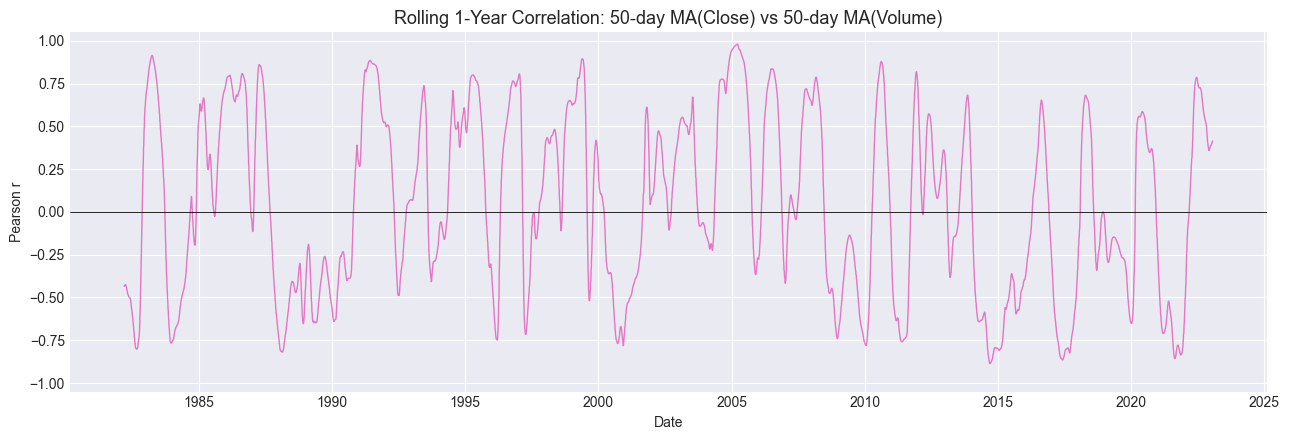

In [24]:
# Rolling 1-year correlation between price-MA and volume-MA over time
rolling_corr = joined["MA_Close"].rolling(252).corr(joined["MA_Volume"])

fig, ax = plt.subplots(figsize=(13, 4.5))
ax.plot(rolling_corr.index, rolling_corr, color="#e377c2", lw=1)
ax.axhline(0, color="k", lw=0.6)
ax.set_title("Rolling 1-Year Correlation: 50-day MA(Close) vs 50-day MA(Volume)")
ax.set_ylabel("Pearson r"); ax.set_xlabel("Date"); ax.set_ylim(-1.05, 1.05)
plt.tight_layout(); plt.show()

**Finding.** The relationship is **regime-dependent**. In the **early era**
(<=2004) the smoothed price and smoothed volume are *positively* correlated
(r = +0.51 — both rose together), but in the **modern era** (2005-2023) the
correlation turns strongly **negative** (r = -0.62), which even drags the
**full-sample** value negative (r = -0.28). As the price climbed into the
hundreds, share-count volume actually fell (helped by the 4-for-1 split in 2020
and a maturing, less-frenzied share turnover). The rolling correlation confirms
this by **flipping sign repeatedly** over time. This is a clean demonstration that
a single full-sample correlation can *mask* a relationship that reverses across
regimes.

## 6. Summary and Insights

**Data quality.** 10,608 clean business-day observations (Jan 1981 -> Jan 2023),
no missing values or duplicate dates. The series is business-day frequency, not
continuous-daily — weekends/holidays produce regular calendar gaps.

**Trend & visualization.** AAPL was nearly flat for ~25 years then grew
exponentially after ~2005; a **log-scale** chart is essential to see the early
decades. The manual candlestick chart resolves short-term OHLC structure that the
long-run line plot hides.

**Descriptive statistics.** Every price column is strongly **right-skewed**
(mean >> median): the distribution is dominated by the recent high-price era and is
non-stationary, which is why we analyse **returns** rather than raw prices for
inference.

**Hypothesis testing.**
- A Welch t-test finds 2021 vs 2022 mean closing prices significantly different —
  but this is partly an artefact of strong price autocorrelation, so the result
  confirms what the chart shows rather than adding rigorous new evidence.
- Daily returns are **decisively non-normal** (D'Agostino-Pearson & Jarque-Bera
  p ~ 0): they exhibit **excess kurtosis / fat tails** — the central financial
  stylised fact, with direct implications for risk modelling.

**Advanced techniques.**
- **SciPy signal processing:** Savitzky-Golay smoothing preserves turning points
  better than a `np.convolve` boxcar average; `detrend` exposes the residual cycle.
- **NumPy correlation:** OHLC prices are almost perfectly collinear (r ~ 1).
  The price-MA <-> volume-MA correlation is **regime-dependent** — *positive* in the
  early era (<=2004, r = +0.51) but *negative* in the modern era (2005-2023,
  r = -0.62), even dragging the full-sample value negative (r = -0.28) — showing
  why rolling/windowed analysis beats a single aggregate statistic.

**Investment takeaway.** Long-run AAPL is a powerful compounder, but its
fat-tailed daily returns mean large single-day moves are far more likely than a
normal model implies — position sizing and risk controls should assume tail risk.


## 7. Reflection

**Challenges and solutions**

1. **Ambiguous date format.** Dates are `DD/MM/YYYY`; a naive parse misreads
   day/month. *Solution:* `pd.read_csv(..., parse_dates=["Date"], dayfirst=True)`,
   verified against known min/max dates.

2. **No `mplfinance` for candlesticks.** *Solution:* drew candlesticks from
   Matplotlib primitives (`vlines` wicks + `bar` bodies) on a **categorical**
   x-axis so weekend gaps don't leave blanks.

3. **Extreme scale / non-stationarity.** A ~1000x price range made early years
   invisible on a linear axis and the mean unrepresentative. *Solution:* added a
   **log-scale** plot and pivoted inference to **returns**.

4. **Choosing the right normality test.** Shapiro-Wilk is unreliable beyond ~5,000
   samples (we have >10,000). *Solution:* used **D'Agostino-Pearson** and
   **Jarque-Bera**, corroborated by a **Q-Q plot**.

5. **Autocorrelation breaks t-test independence.** Daily prices are serially
   correlated, inflating significance. *Solution:* flagged the caveat explicitly
   and recommended return-based inference as the statistically sound alternative.

6. **Aggregate correlation hides regime shifts.** A single `np.corrcoef` value
   averaged out opposite-signed relationships. *Solution:* computed
   **rolling/windowed** correlations to reveal the sign reversal.

**What I'd do next:** test for stationarity (ADF test), model volatility clustering
with GARCH, and decompose seasonality — natural extensions of this foundation.
